In [4]:
import time 
import random
import matplotlib.pyplot as plt
def constant_time_example(arr):
    if len(arr) > 0:
        return arr[0]
    return None
def binary_search(arr,target):
    left,right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return - 1 
def sum_array(arr):
    total = 0
    for num in arr:
        total += num
    return total
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left_half = arr[:mid]
    right_half = arr[mid:]
    sorted_left = merge_sort(left_half)
    sorted_right = merge_sort(right_half)
    return merge(sorted_left,sorted_right)
def merge(left,right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0,n-i-1):
            if arr[j] > arr[j+1]:
                arr[j],arr[j+1] = arr[j+1],arr[j]
    return arr
def time_algorithm(func,input_size,num_runs=10):
    total_time = 0
    for _ in range(num_runs):
        data = [random.randint(0,1000) for _ in range(input_size)]
        if func == binary_search or func == merge_sort:
            data.sort()
        start_time = time.time()
        if func == binary_search:
            func(data,target=random.choice(data))
        else:
            func(data)
        end_time = time.time()
        total_time += (end_time - start_time)
    return total_time / num_runs
def plot_complexity(input_sizes,times_dict,title,loglog=False):
    plt.figure(figsize=(12,8))
    for name,times in times_dict.items():
        if loglog:
            plt.loglog(input_sizes,times,'o-',label=f'{name}(O{get_complexity_order(name)}))')
        else:
            plt.plot(input_sizes,times,'o-',label=f'{name}(O({get_complexity_order(name)}))')
    plt.xlabel('Input Size')
    plt.ylabel('Time(s)')
    if loglog:
        plt.xlabel('Input Size (log scale)')
        plt.ylabel('Time (s, log scale)')
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.show()
def get_complexity_order(name):
    orders ={
        'constant_time_example':'1',
        'binary_search':'log n',
        'sum_array':'n',
        'merge_sort':'n '
    }


In [1]:
import numpy as np
import matplotlib.pyplot as plt
img = plt.imread('D:\pythonprojects\practice-github\20260612\image\3.jpg')
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]
print("图像的 NumPy 数组形状:", img.shape)   # (5, 5, 3)
print("\nR 通道矩阵 (亮度值):")
print(R)
print("\nG 通道矩阵 (亮度值):")
print(G)
print("\nB 通道矩阵 (亮度值):")
print(B)
fig,axes = plt.subplots(1,4,figsize=(12,3))
axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[1].imshow(R,cmap='gray')
axes[1].set_title("Red Channel")
axes[2].imshow(G,cmap='gray')
axes[2].set_title("Green Channel")
axes[3].imshow(B,cmap='gray')
axes[3].set_title("Blue Channel")
plt.right_layout()
plt.show()

<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_5192\4039719271.py:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  img = plt.imread('D:\pythonprojects\practice-github\20260612\image\3.jpg')


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\pythonprojects\\practice-github\x8260612\\image\x03.jpg'

--- 归一化后图像数据信息 ---
数据类型: float32
数值范围: 最小值 = 0.0000, 最大值 = 1.0000

示例数据 (归一化后图像的第一个通道，左上角 5x5 像素块):
[[0.2627451  0.2627451  0.27450982 0.27450982 0.28235295]
 [0.2627451  0.2627451  0.27058825 0.2784314  0.28235295]
 [0.2627451  0.2627451  0.27058825 0.2784314  0.28627452]
 [0.2627451  0.2627451  0.27058825 0.27450982 0.28627452]
 [0.25882354 0.2627451  0.27058825 0.27450982 0.28235295]]
---------------------------------



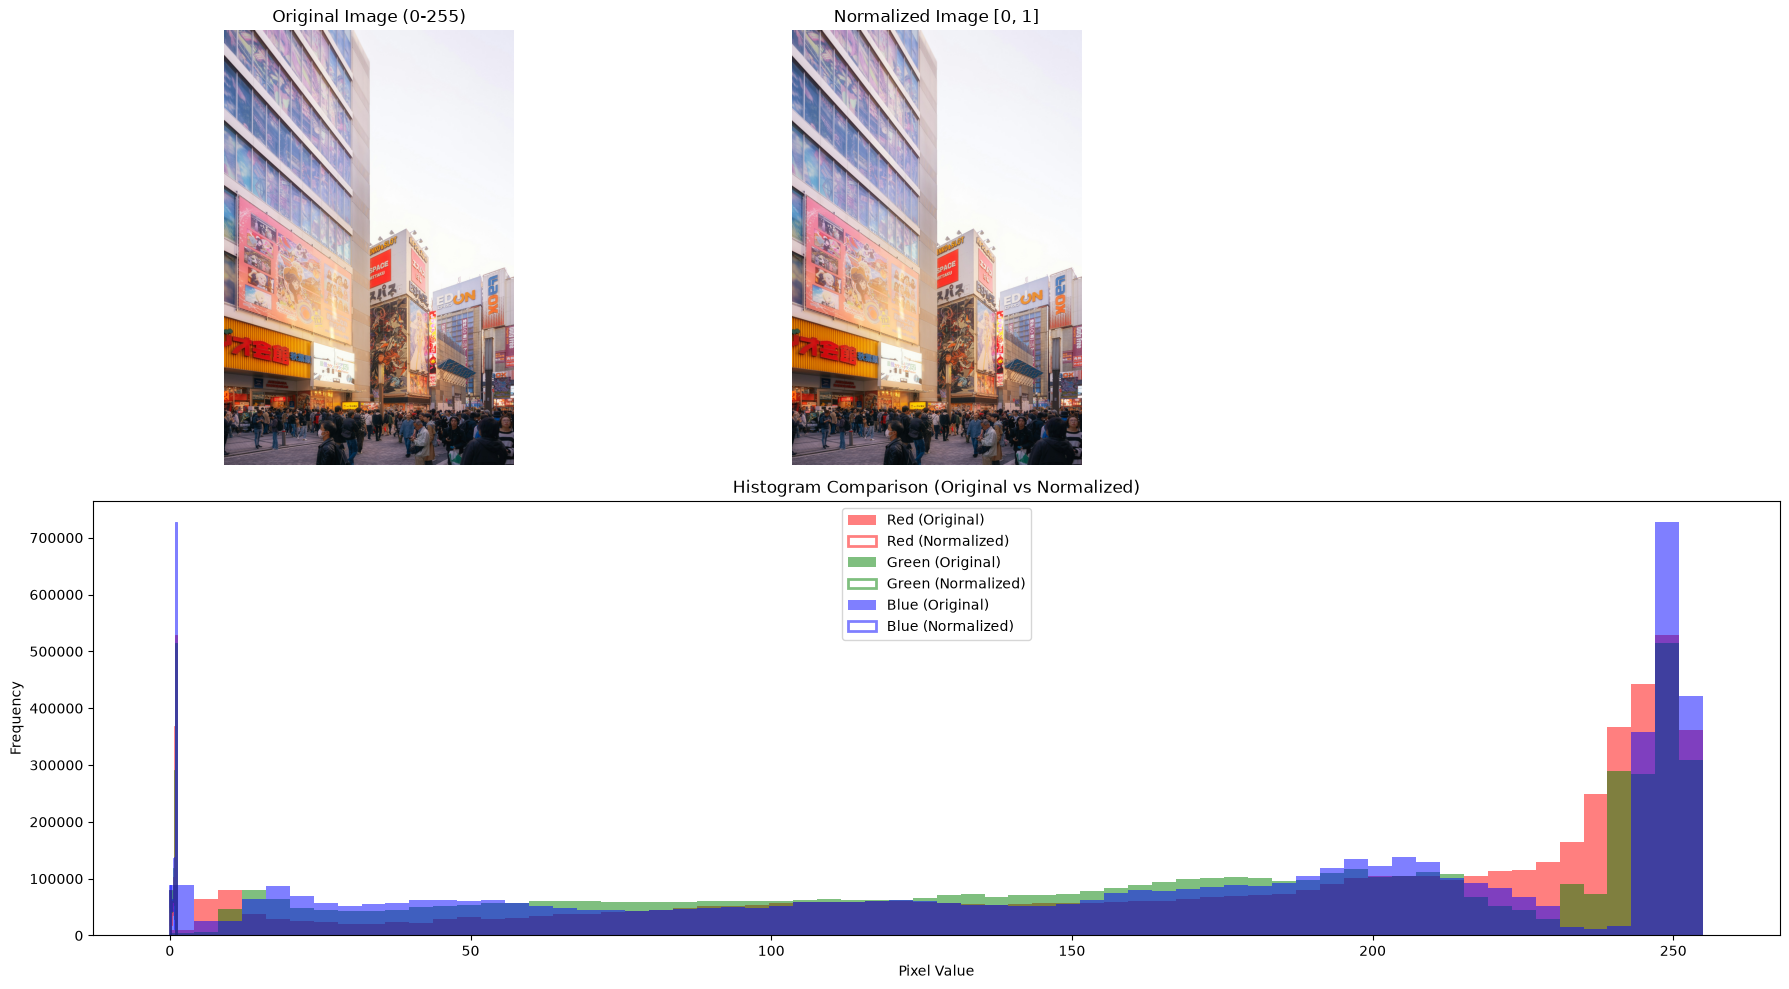

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 图像路径
img_path = r'D:\pythonprojects\practice-github\20260612\image\3.jpg'

try:
    # 1. 读取图像
    img = plt.imread(img_path)
except FileNotFoundError:
    print(f"错误: 找不到文件 '{img_path}'")
    exit()

# 2. 转换为 float32 类型
img_float = img.astype(np.float32)

# 3. 定义并应用归一化函数
def normalize_minmax_01(img):
    """将图像像素值归一化到 [0, 1] 范围"""
    min_val = img.min()
    max_val = img.max()
    if max_val == min_val:
        return np.zeros_like(img)
    return (img - min_val) / (max_val - min_val)

img_norm_01 = normalize_minmax_01(img_float)

# --- 查看归一化后的数值 ---
print("--- 归一化后图像数据信息 ---")
print(f"数据类型: {img_norm_01.dtype}")
print(f"数值范围: 最小值 = {img_norm_01.min():.4f}, 最大值 = {img_norm_01.max():.4f}")
# 打印第一个通道（例如R通道）的前5x5像素块，方便直观查看数值
if img_norm_01.ndim == 3: # 如果是彩色图像
    print("\n示例数据 (归一化后图像的第一个通道，左上角 5x5 像素块):")
    print(img_norm_01[0:5, 0:5, 0])
else: # 如果是灰度图像
    print("\n示例数据 (归一化后图像，左上角 5x5 像素块):")
    print(img_norm_01[0:5, 0:5])
print("---------------------------------\n")

# --- 新增：绘制直方图对比 ---

# 确定图像类型并设置颜色
if img.ndim == 2: # 灰度图像
    channel_names = ['Gray']
    colors = ['gray']
    imgs_to_plot = [img]
    imgs_norm_to_plot = [img_norm_01]
elif img.ndim == 3 and img.shape[2] == 3: # 彩色图像 (RGB)
    channel_names = ['Red', 'Green', 'Blue']
    colors = ['red', 'green', 'blue']
    # 分离RGB通道
    imgs_to_plot = [img[:, :, 0], img[:, :, 1], img[:, :, 2]]
    imgs_norm_to_plot = [img_norm_01[:, :, 0], img_norm_01[:, :, 1], img_norm_01[:, :, 2]]
else:
    print("不支持的图像格式。")
    exit()

# 创建一个大的画布，用于放置所有子图
# 如果是彩色图，我们创建2行3列的子图 (原始图像, 归一化图像, 直方图对比)
# 如果是灰度图，我们创建2行2列的子图
if img.ndim == 3:
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3)
else:
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2)

# 第一行：显示原始图像和归一化图像
ax_orig = fig.add_subplot(gs[0, 0])
ax_orig.imshow(img)
ax_orig.set_title("Original Image (0-255)")
ax_orig.axis('off')

ax_norm = fig.add_subplot(gs[0, 1])
ax_norm.imshow(img_norm_01)
ax_norm.set_title("Normalized Image [0, 1]")
ax_norm.axis('off')

# 第二行：绘制直方图对比
ax_hist = fig.add_subplot(gs[1, :])

# 为每个通道绘制直方图
for i in range(len(channel_names)):
    # 原始图像的直方图 (0-255)
    ax_hist.hist(imgs_to_plot[i].flatten(), bins=64, range=(0, 255), 
                   color=colors[i], alpha=0.5, label=f'{channel_names[i]} (Original)')
    
    # 归一化后图像的直方图 (0-1)
    ax_hist.hist(imgs_norm_to_plot[i].flatten(), bins=64, range=(0, 1), 
                   color=colors[i], alpha=0.5, histtype='step', linewidth=2, label=f'{channel_names[i]} (Normalized)')

ax_hist.set_xlabel('Pixel Value')
ax_hist.set_ylabel('Frequency')
ax_hist.set_title('Histogram Comparison (Original vs Normalized)')
ax_hist.legend()

plt.tight_layout()
plt.show()

In [ ]:
import os
os.listdir('image')

['1.png', '2.png', '3.jpg', '5.jpg']

(2875, 1920, 3) uint8


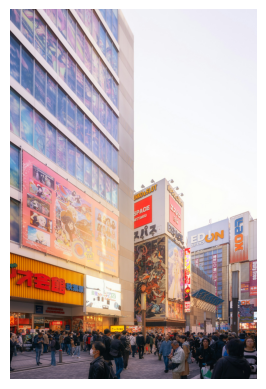

(2875, 1920) uint8


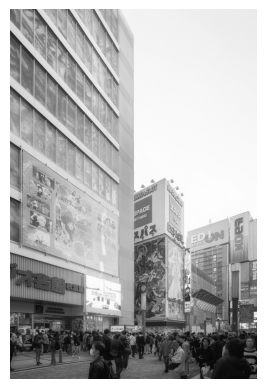

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img= cv2.imread('image/3.jpg')
print(img.shape, img.dtype)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()
cv2.imwrite('output.jpg',img)

img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
print(img_gray.shape,img_gray.dtype)
plt.imshow(img_gray,cmap='gray')
plt.axis('off')
plt.show()
cv2.imwrite('output_gray.jpg',img_gray)


(2875, 1920, 3) uint8


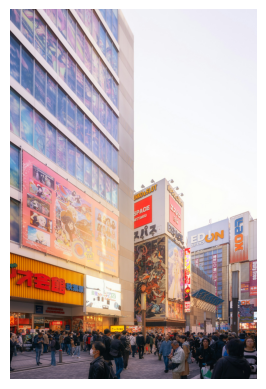

(2875, 1920) uint8


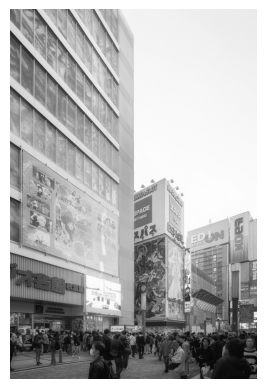

True

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img= cv2.imread('image/3.jpg')
print(img.shape, img.dtype)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()
cv2.imwrite('output.jpg',img)
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
print(img_gray.shape,img_gray.dtype)
plt.imshow(img_gray,cmap='gray')
plt.axis('off')
plt.show()
cv2.imwrite('output_gray.jpg',img_gray)



In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img= cv2.imread('image/3.jpg')
h,w,c = img.shape
print('height=',h,'width=',w,'channel=',c)
b,g,r = img[100,200]
print(b,g,r)
bright = np.clip(img.astype(np))

height= 2875 width= 1920 channel= 3
153 116 124


ValueError: Could not convert <module 'numpy' from 'c:\\Users\\yuhao.bian\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\numpy\\__init__.py'> to a NumPy dtype (via `.dtype` value <class 'numpy.dtype'>).

(2875, 1920, 3) uint8


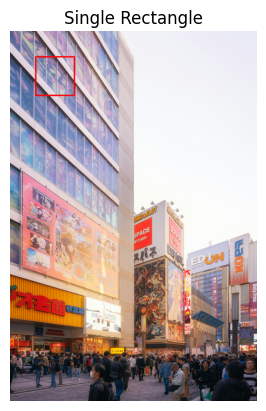

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img= cv2.imread('image/3.jpg')
print(img.shape, img.dtype)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
cv2.rectangle(img,(500,500),(200,200),(0,0,255),10)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Single Rectangle')
plt.show()



(2875, 1920, 3) uint8


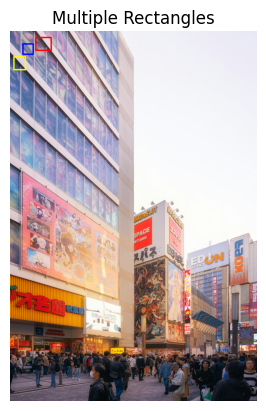

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('image/3.jpg')
print(img.shape, img.dtype)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
rectangles = [
    (100, 100, 180, 180, (255, 0, 0), 10),
    (200, 50, 320, 150, (0, 0, 255), 10),
    (30, 200, 120, 300, (0, 255, 255), 10)
]
for (x1,y1,x2,y2,color,thickness) in rectangles:
    cv2.rectangle(img,(x1,y1),(x2,y2),color,thickness)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Multiple Rectangles')
plt.show()

(2875, 1920, 3) uint8


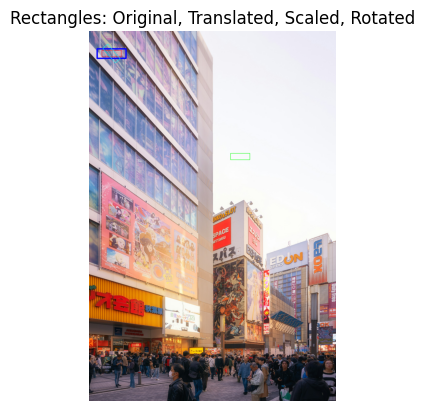

True

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取原图
img = cv2.imread('image/3.jpg')
print(img.shape, img.dtype)

# 2. 创建一个副本用于绘图，避免污染原图
img_draw = img.copy()
h, w = img_draw.shape[:2]

# 3. 定义基础矩形（左上角，右下角）
x1, y1, x2, y2 = 100, 150, 250, 200

# ---------- 4. 绘制原始矩形（红色）----------
cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 0, 255), 2)

# ---------- 5. 平移矩形（绿色）----------
dx, dy = 1000, 800   # 向右平移100，向下平移50
cv2.rectangle(img_draw,
              (x1 + dx, y1 + dy),
              (x2 + dx, y2 + dy),
              (0, 255, 0), 2)

# ---------- 6. 放大/缩小矩形（蓝色）----------
# 以原始矩形的中心为基准，放大1.5倍
cx = (x1 + x2) // 2
cy = (y1 + y2) // 2
bw = x2 - x1          # 原宽
bh = y2 - y1          # 原高
scale = 1.5           # 缩放因子

new_w = int(bw * scale)
new_h = int(bh * scale)
# 由中心反推新左上角
x1_s = cx - new_w // 2
y1_s = cy - new_h // 2
x2_s = cx + new_w // 2
y2_s = cy + new_h // 2

cv2.rectangle(img_draw,
              (x1_s, y1_s),
              (x2_s, y2_s),
              (255, 0, 0), 10)   # 蓝色

# ---------- 7. 旋转矩形（青色）----------
angle = 50   # 逆时针旋转30度
# 创建旋转矩形对象：中心、尺寸(宽,高)、角度
rot_rect = ((cx, cy), (bw, bh), angle)
# 得到4个顶点坐标（浮点型）
box = cv2.boxPoints(rot_rect)
# 转为整数，用于绘制
box = np.intp(box)
# 绘制轮廓（-1也可用0表示绘制所有轮廓点）
cv2.drawContours(img_draw, [box], 0, (255, 255, 0), 2)   # 青色

# 8. 转换为RGB，供matplotlib显示
img_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Rectangles: Original, Translated, Scaled, Rotated')
plt.show()

# 9. 保存结果
cv2.imwrite('rect_transforms.jpg', img_draw)